# Task 2: Financial News Sentiment Classification

**Pipeline:**
1. Imports & Config
2. Helper Functions
3. Stage 1 — Data Loading & EDA
4. Stage 2 — Preprocessing & Split
5. Stage 3A — Method A: Naive Bayes (non-DL baseline)
6. Stage 3B — Method B: DistilBERT (deep learning)
7. Stage 3C — Improvement Experiment: DistilBERT with Class Weights
8. Stage 4 — Model Comparison
9. Stage 5 — Final Test Evaluation
10. Stage 6 — Error Analysis
11. Save Results

In [1]:
# =============================================================
# Cell 1 — ALL imports and global config
# =============================================================
import re
import logging
import warnings
warnings.filterwarnings('ignore')
# Suppress HuggingFace weight-loading info messages (UNEXPECTED/MISSING keys)
# These are expected when loading a masked-LM checkpoint for sequence classification.
logging.getLogger('transformers.modeling_utils').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

# PyTorch
import torch

# HuggingFace
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
import evaluate

# ---- Global config ----
RANDOM_STATE = 42
BERT_MODEL   = 'distilbert-base-uncased'
BERT_MAX_LEN = 64
BERT_EPOCHS  = 5           # increased from 3; EarlyStoppingCallback will stop if val F1 plateaus
LABEL2ID     = {'negative': 0, 'neutral': 1, 'positive': 2}
ID2LABEL     = {v: k for k, v in LABEL2ID.items()}
LABEL_ORDER  = ['negative', 'neutral', 'positive']

plt.rcParams['figure.dpi'] = 120
print('All imports OK.')

All imports OK.


In [2]:
# =============================================================
# Cell 2 — Helper Functions
# =============================================================

# ---- Preprocessing (used by NB only) ----
def preprocess_text(text: str) -> str:
    """Finance-aware normalisation for bag-of-words models.
    NOT applied to BERT: DistilBERT's pre-training already encodes
    numerical/monetary context, so replacing tokens would discard that signal.
    """
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' URL ', text)
    text = re.sub(r'\$[a-z]{1,6}\b', ' TICKER ', text)
    text = re.sub(r'\bq[1-4]\b', ' QUARTER ', text)
    text = re.sub(r'\b(?:19|20)\d{2}\b', ' YEAR ', text)
    text = re.sub(r'\b\d+(?:[\.,]\d+)?\s*%\b', ' PERCENT ', text)
    text = re.sub(r'\b(?:eur|usd|gbp|jpy|cny|cad|aud|chf)\b', ' CURRENCY ', text)
    text = re.sub(r'\b\d+(?:[\.,]\d+)?\s*(?:m|mn|million|b|bn|billion|k|thousand)\b', ' MONEY ', text)
    text = re.sub(r'\b\d+(?:[\.,]\d+)?\b', ' NUM ', text)
    text = re.sub(r'[^a-z0-9%\$\.\-\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# ---- Sklearn evaluation ----
def evaluate_sklearn(name, model, X_train, y_train, X_eval, y_eval):
    model.fit(X_train, y_train)
    preds = model.predict(X_eval)
    summary = {
        'model':       name,
        'accuracy':    accuracy_score(y_eval, preds),
        'macro_f1':    f1_score(y_eval, preds, average='macro'),
        'weighted_f1': f1_score(y_eval, preds, average='weighted')
    }
    return model, preds, summary


def plot_confusion(y_true, y_pred, labels, title):
    cm   = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(title)
    plt.tight_layout()
    plt.show()


def error_df(X_eval, y_true, y_pred, n=25):
    df = pd.DataFrame({
        'text': X_eval.reset_index(drop=True),
        'true': y_true.reset_index(drop=True),
        'pred': pd.Series(y_pred)
    })
    errors = df[df['true'] != df['pred']].copy()
    return errors.head(n), errors


# ---- BERT metrics ----
_acc_metric = evaluate.load('accuracy')
_f1_metric  = evaluate.load('f1')

def compute_bert_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy':    _acc_metric.compute(predictions=preds, references=labels)['accuracy'],
        'macro_f1':    _f1_metric.compute(predictions=preds, references=labels, average='macro')['f1'],
        'weighted_f1': _f1_metric.compute(predictions=preds, references=labels, average='weighted')['f1'],
    }


# ---- Training curve plot ----
def plot_training_curves(log_history, title='Training curves'):
    """Extract per-epoch eval metrics from Trainer.state.log_history and plot."""
    records = [e for e in log_history if 'eval_loss' in e]
    if not records:
        print('No eval records found in log_history.')
        return

    epochs    = [r['epoch']        for r in records]
    eval_loss = [r['eval_loss']     for r in records]
    macro_f1  = [r.get('eval_macro_f1', r.get('eval_macro_f1', None)) for r in records]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # Loss curve
    axes[0].plot(epochs, eval_loss, marker='o', linewidth=1.5)
    axes[0].set_title('Validation loss per epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)

    # Macro F1 curve
    if any(v is not None for v in macro_f1):
        axes[1].plot(epochs, macro_f1, marker='o', color='tab:orange', linewidth=1.5)
        axes[1].set_title('Validation macro F1 per epoch')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Macro F1')
        axes[1].grid(True, alpha=0.3)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


# ---- HuggingFace dataset builder ----
def make_hf_dataset(X_series, y_series, encode_labels=True):
    """Build a HuggingFace Dataset from pandas Series.
    encode_labels=True  -> maps string labels to int via LABEL2ID (for BERT training).
    encode_labels=False -> keeps raw string labels (not used here but useful for inspection).
    """
    labels = y_series.map(LABEL2ID) if encode_labels else y_series
    return Dataset.from_dict({
        'text':  X_series.reset_index(drop=True).tolist(),
        'label': labels.reset_index(drop=True).tolist()
    })


print('Helper functions defined.')

Helper functions defined.


---
## Stage 1 — Data Loading & EDA

In [3]:
# =============================================================
# Cell 3 — Load & inspect raw data
# =============================================================
df = pd.read_csv('data.csv')

text_col  = next(c for c in df.columns if c.lower() in ('sentence', 'text', 'phrase', 'news', 'content'))
label_col = next(c for c in df.columns if c.lower() in ('sentiment', 'label', 'target', 'class'))

print(f'Shape: {df.shape}  |  text_col: {text_col!r}  |  label_col: {label_col!r}')
print(df[[text_col, label_col]].head())

Shape: (5842, 2)  |  text_col: 'Sentence'  |  label_col: 'Sentiment'
                                            Sentence Sentiment
0  The GeoSolutions technology will leverage Bene...  positive
1  $ESI on lows, down $1.50 to $2.50 BK a real po...  negative
2  For the last quarter of 2010 , Componenta 's n...  positive
3  According to the Finnish-Russian Chamber of Co...   neutral
4  The Swedish buyout firm has sold its remaining...   neutral


Label distribution:
Sentiment
neutral     3130
positive    1852
negative     860
Name: count, dtype: int64


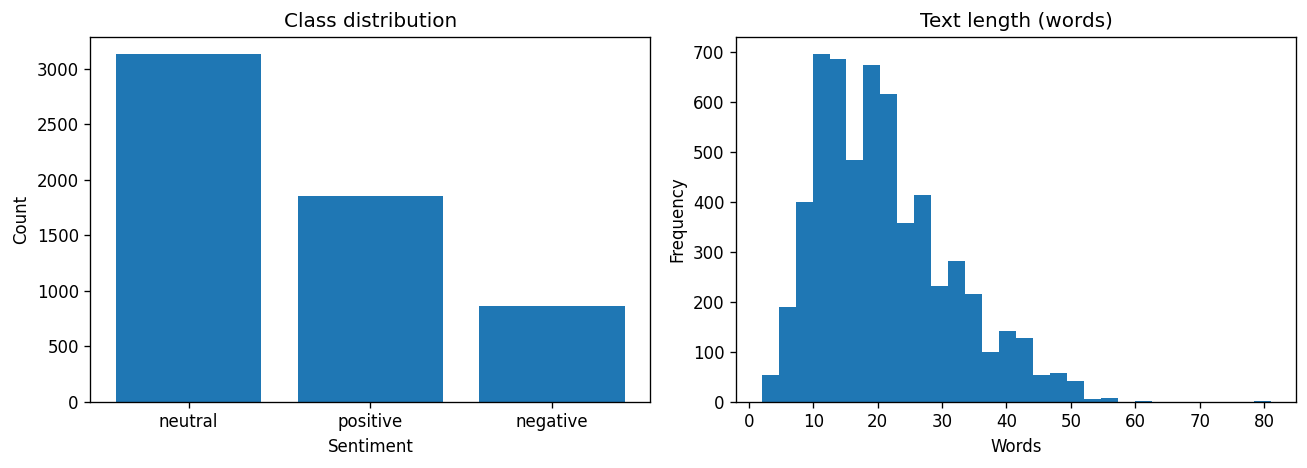

Avg length: 21.0 words  |  Median: 19 words


In [4]:
# =============================================================
# Cell 4 — Clean labels, drop nulls, EDA plots
# =============================================================
df = df[[text_col, label_col]].dropna().copy()
df[text_col]  = df[text_col].astype(str)
df[label_col] = df[label_col].astype(str).str.strip().str.lower()
df = df[df[label_col].isin({'positive', 'negative', 'neutral'})].copy()

print('Label distribution:')
print(df[label_col].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df[label_col].value_counts()
axes[0].bar(counts.index, counts.values)
axes[0].set_title('Class distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')

df['_len'] = df[text_col].str.split().apply(len)
axes[1].hist(df['_len'], bins=30)
axes[1].set_title('Text length (words)')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
print(f'Avg length: {df["_len"].mean():.1f} words  |  Median: {df["_len"].median():.0f} words')

---
## Stage 2 — Preprocessing & Train/Val/Test Split

In [5]:
# =============================================================
# Cell 5 — Preprocessing and split
#
# Two text columns are maintained:
#   X_raw   -> original text,   used by BERT (preserves numerical/monetary context)
#   X_clean -> preprocessed,    used by NB   (normalises numbers/amounts for BoW)
# =============================================================
df['clean'] = df[text_col].apply(preprocess_text)

print('Preprocessing examples (first 3 rows):')
print(df[[text_col, 'clean']].head(3).to_string(index=False))

y = df[label_col]

# Stratified 70 / 15 / 15 split on indices
idx = df.index
idx_train, idx_tmp, y_train, y_tmp = train_test_split(
    idx, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_tmp, y_tmp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_tmp)

# NB inputs (preprocessed)
X_train_nb = df.loc[idx_train, 'clean']
X_val_nb   = df.loc[idx_val,   'clean']
X_test_nb  = df.loc[idx_test,  'clean']

# BERT inputs (raw original text)
X_train_bert = df.loc[idx_train, text_col]
X_val_bert   = df.loc[idx_val,   text_col]
X_test_bert  = df.loc[idx_test,  text_col]

print(f'\nTrain: {len(idx_train)}  |  Val: {len(idx_val)}  |  Test: {len(idx_test)}')

Preprocessing examples (first 3 rows):
                                                                                                                                                                                                                  Sentence                                                                                                                                                                                                                 clean
The GeoSolutions technology will leverage Benefon 's GPS solutions by providing Location Based Search Technology , a Communities Platform , location relevant multimedia content and a new and powerful commercial model . the geosolutions technology will leverage benefon s gps solutions by providing location based search technology a communities platform location relevant multimedia content and a new and powerful commercial model .
                                                                                               

---
## Stage 3A — Method A: Naive Bayes (non-deep-learning baseline)

In [6]:
# =============================================================
# Cell 6 — NB: tune on train set
# =============================================================
nb_pipeline = Pipeline([
    ('vect', CountVectorizer(lowercase=False, ngram_range=(1, 2), min_df=2)),
    ('clf',  MultinomialNB())
])

nb_param_grid = {
    'vect__ngram_range': [(1, 1), (1, 2)],
    'vect__min_df':      [2, 3],
    'clf__alpha':        [0.1, 0.5, 1.0, 2.0]
}

nb_grid = GridSearchCV(
    estimator=nb_pipeline, param_grid=nb_param_grid,
    scoring='f1_macro', cv=5, n_jobs=1, verbose=1
)
nb_grid.fit(X_train_nb, y_train)

print(f'Best NB params:   {nb_grid.best_params_}')
print(f'Best CV macro-F1: {nb_grid.best_score_:.4f}')
best_nb = nb_grid.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best NB params:   {'clf__alpha': 1.0, 'vect__min_df': 3, 'vect__ngram_range': (1, 1)}
Best CV macro-F1: 0.6436


NB validation summary: {'model': 'CountVec + MultinomialNB (tuned)', 'accuracy': 0.6883561643835616, 'macro_f1': 0.6296420391335645, 'weighted_f1': 0.6950543471927265}

              precision    recall  f1-score   support

    negative     0.3675    0.4729    0.4136       129
     neutral     0.7719    0.7505    0.7611       469
    positive     0.7480    0.6835    0.7143       278

    accuracy                         0.6884       876
   macro avg     0.6291    0.6356    0.6296       876
weighted avg     0.7048    0.6884    0.6951       876



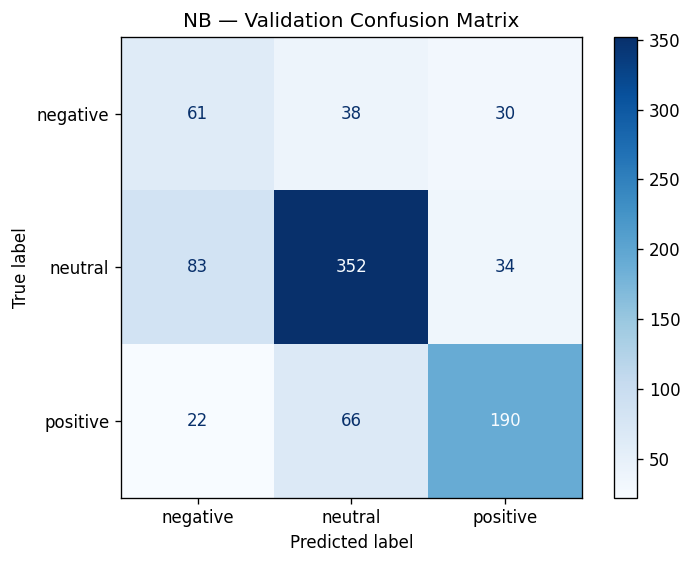


Top 15 features per class (by log-probability):
  negative: the, in, to, of, from, and, for, profit, on, down, net, finnish, year, by, sales
  neutral: the, of, in, and, to, for, is, will, on, company, as, be, from, at, by
  positive: the, to, in, of, and, for, from, on, its, sales, profit, with, net, year, by


In [7]:
# =============================================================
# Cell 7 — NB: evaluate on validation set
# =============================================================
nb_val_pred = best_nb.predict(X_val_nb)

nb_val_summary = {
    'model':       'CountVec + MultinomialNB (tuned)',
    'accuracy':    accuracy_score(y_val, nb_val_pred),
    'macro_f1':    f1_score(y_val, nb_val_pred, average='macro'),
    'weighted_f1': f1_score(y_val, nb_val_pred, average='weighted')
}

print('NB validation summary:', nb_val_summary)
print()
print(classification_report(y_val, nb_val_pred, target_names=LABEL_ORDER, digits=4))
plot_confusion(y_val, nb_val_pred, LABEL_ORDER, 'NB — Validation Confusion Matrix')

# Feature importance: top 15 words per class
vect_nb       = best_nb.named_steps['vect']
clf_nb        = best_nb.named_steps['clf']
feature_names = np.array(vect_nb.get_feature_names_out())

print('\nTop 15 features per class (by log-probability):')
for i, cls in enumerate(clf_nb.classes_):
    top_idx = np.argsort(clf_nb.feature_log_prob_[i])[-15:][::-1]
    print(f"  {cls}: {', '.join(feature_names[top_idx])}")

---
## Stage 3B — Method B: DistilBERT (deep learning, standard fine-tuning)

In [8]:
# =============================================================
# Cell 8 — BERT: tokenize (using RAW text, not preprocessed)
# Rationale: DistilBERT's pre-training encodes numbers and monetary
# expressions in context. Replacing them with placeholder tokens
# (NUM, MONEY, etc.) would discard that signal.
# =============================================================
train_ds = make_hf_dataset(X_train_bert, y_train)
val_ds   = make_hf_dataset(X_val_bert,   y_val)
test_ds  = make_hf_dataset(X_test_bert,  y_test)

tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, padding='max_length', max_length=BERT_MAX_LEN)

train_ds = train_ds.map(tokenize, batched=True).remove_columns(['text']).with_format('torch')
val_ds   = val_ds.map(tokenize,   batched=True).remove_columns(['text']).with_format('torch')
test_ds  = test_ds.map(tokenize,  batched=True).remove_columns(['text']).with_format('torch')

print('Datasets ready (raw text, no token replacement).')
print(train_ds)

Map:   0%|          | 0/4089 [00:00<?, ? examples/s]

Map:   0%|          | 0/876 [00:00<?, ? examples/s]

Map:   0%|          | 0/877 [00:00<?, ? examples/s]

Datasets ready (raw text, no token replacement).
Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 4089
})


In [9]:
# =============================================================
# Cell 9 — BERT: define model and trainer (weighted loss)
# Early stopping: stop if eval macro_f1 does not improve for 2 epochs.
# =============================================================
import logging
logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)

bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID
)

training_args = TrainingArguments(
    output_dir='./distilbert_sentiment',
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    num_train_epochs=BERT_EPOCHS,       # up to 5; early stopping may halt earlier
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    save_total_limit=1,
    report_to='none'
)

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_bert_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]  # stop if no improvement for 2 epochs
)

print('Trainer ready (max epochs=5, early stopping patience=2).')

The following layers were not sharded: distilbert.transformer.layer.*.attention.k_lin.weight, distilbert.transformer.layer.*.ffn.lin1.bias, classifier.bias, distilbert.transformer.layer.*.sa_layer_norm.weight, pre_classifier.weight, distilbert.transformer.layer.*.ffn.lin2.weight, distilbert.transformer.layer.*.attention.q_lin.weight, distilbert.embeddings.LayerNorm.bias, distilbert.transformer.layer.*.attention.v_lin.bias, classifier.weight, distilbert.transformer.layer.*.output_layer_norm.bias, pre_classifier.bias, distilbert.embeddings.LayerNorm.weight, distilbert.embeddings.word_embeddings.weight, distilbert.transformer.layer.*.output_layer_norm.weight, distilbert.transformer.layer.*.attention.out_lin.bias, distilbert.transformer.layer.*.attention.v_lin.weight, distilbert.transformer.layer.*.ffn.lin1.weight, distilbert.transformer.layer.*.ffn.lin2.bias, distilbert.transformer.layer.*.attention.q_lin.bias, distilbert.transformer.layer.*.attention.k_lin.bias, distilbert.transformer.la

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Trainer ready (max epochs=5, early stopping patience=2).


---
## Stage 3C — Improvement Experiment: DistilBERT with Class Weights

The `negative` class is severely under-represented (≈13% of data).
A custom `Trainer` subclass computes a weighted cross-entropy loss,
assigning higher penalty to misclassifying minority classes.
This is compared against the standard fine-tuning above.

In [10]:
# =============================================================
# Cell 13 — Weighted BERT: compute class weights from training labels
# =============================================================
classes      = np.array([0, 1, 2])
y_train_int  = y_train.map(LABEL2ID).values

weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_int)
class_weights_tensor = torch.tensor(weights, dtype=torch.float)

print('Class weights (balanced):')
for i, w in enumerate(weights):
    print(f'  {ID2LABEL[i]}: {w:.4f}')

Class weights (balanced):
  negative: 2.2641
  neutral: 0.6221
  positive: 1.0517


In [11]:
# =============================================================
# Cell 14 — Weighted BERT: define custom Trainer with weighted loss
# =============================================================
class WeightedLossTrainer(Trainer):
    """Trainer subclass that replaces the default cross-entropy loss
    with a class-weighted version to penalise minority-class errors more.
    """
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits
        loss_fn = torch.nn.CrossEntropyLoss(
            weight=class_weights_tensor.to(logits.device)
        )
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


bert_model_weighted = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID
)

training_args_weighted = TrainingArguments(
    output_dir='./distilbert_weighted',
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    num_train_epochs=BERT_EPOCHS,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    save_total_limit=1,
    report_to='none'
)

trainer_weighted = WeightedLossTrainer(
    model=bert_model_weighted,
    args=training_args_weighted,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_bert_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print('Weighted trainer ready.')

The following layers were not sharded: distilbert.transformer.layer.*.attention.k_lin.weight, distilbert.transformer.layer.*.ffn.lin1.bias, classifier.bias, distilbert.transformer.layer.*.sa_layer_norm.weight, pre_classifier.weight, distilbert.transformer.layer.*.ffn.lin2.weight, distilbert.transformer.layer.*.attention.q_lin.weight, distilbert.embeddings.LayerNorm.bias, distilbert.transformer.layer.*.attention.v_lin.bias, classifier.weight, distilbert.transformer.layer.*.output_layer_norm.bias, pre_classifier.bias, distilbert.embeddings.LayerNorm.weight, distilbert.embeddings.word_embeddings.weight, distilbert.transformer.layer.*.output_layer_norm.weight, distilbert.transformer.layer.*.attention.out_lin.bias, distilbert.transformer.layer.*.attention.v_lin.weight, distilbert.transformer.layer.*.ffn.lin1.weight, distilbert.transformer.layer.*.ffn.lin2.bias, distilbert.transformer.layer.*.attention.q_lin.bias, distilbert.transformer.layer.*.attention.k_lin.bias, distilbert.transformer.la

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Weighted trainer ready.


In [12]:
# =============================================================
# Cell 15 — Weighted BERT: train
# =============================================================
trainer_weighted.train()
print('Weighted training complete.')

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.734634,0.629335,0.754566,0.721934,0.764070
2,0.442018,0.536920,0.756849,0.731929,0.770288
3,0.307714,0.585264,0.762557,0.739268,0.775594
4,0.240242,0.704883,0.769406,0.735412,0.779878
5,0.203165,0.702794,0.768265,0.736285,0.778987


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Weighted training complete.


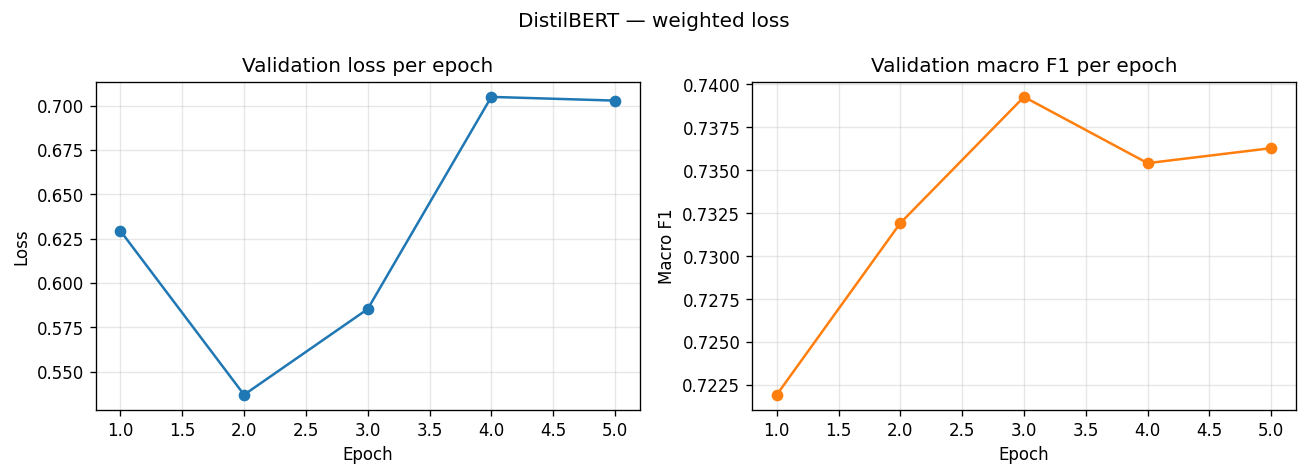

In [13]:
# =============================================================
# Cell 16 — Weighted BERT: training curves
# =============================================================
plot_training_curves(trainer_weighted.state.log_history, title='DistilBERT — weighted loss')

Weighted BERT validation summary: {'model': 'DistilBERT (weighted loss)', 'accuracy': 0.7625570776255708, 'macro_f1': 0.7392677913496818, 'weighted_f1': 0.7755936541237611}

              precision    recall  f1-score   support

    negative     0.4508    0.8527    0.5898       129
     neutral     0.9205    0.6908    0.7893       469
    positive     0.8357    0.8417    0.8387       278

    accuracy                         0.7626       876
   macro avg     0.7357    0.7951    0.7393       876
weighted avg     0.8244    0.7626    0.7756       876



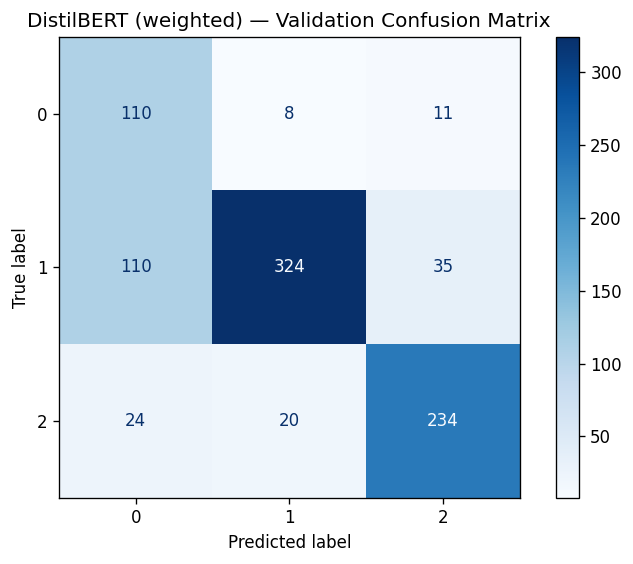

In [14]:
# =============================================================
# Cell 17 — Weighted BERT: evaluate on validation set
# =============================================================
bert_val_true = np.array(val_ds['label'])
val_output_w      = trainer_weighted.predict(val_ds)
bert_w_val_pred   = np.argmax(val_output_w.predictions, axis=-1)

bert_w_val_summary = {
    'model':       'DistilBERT (weighted loss)',
    'accuracy':    accuracy_score(bert_val_true, bert_w_val_pred),
    'macro_f1':    f1_score(bert_val_true, bert_w_val_pred, average='macro'),
    'weighted_f1': f1_score(bert_val_true, bert_w_val_pred, average='weighted')
}

print('Weighted BERT validation summary:', bert_w_val_summary)
print()
print(classification_report(bert_val_true, bert_w_val_pred, target_names=LABEL_ORDER, digits=4))
plot_confusion(bert_val_true, bert_w_val_pred, list(range(3)), 'DistilBERT (weighted) — Validation Confusion Matrix')

---
## Stage 4 — Model Comparison (Validation Set)

Validation results:
                           model  accuracy  macro_f1  weighted_f1
      DistilBERT (weighted loss)  0.762557  0.739268     0.775594
CountVec + MultinomialNB (tuned)  0.688356  0.629642     0.695054


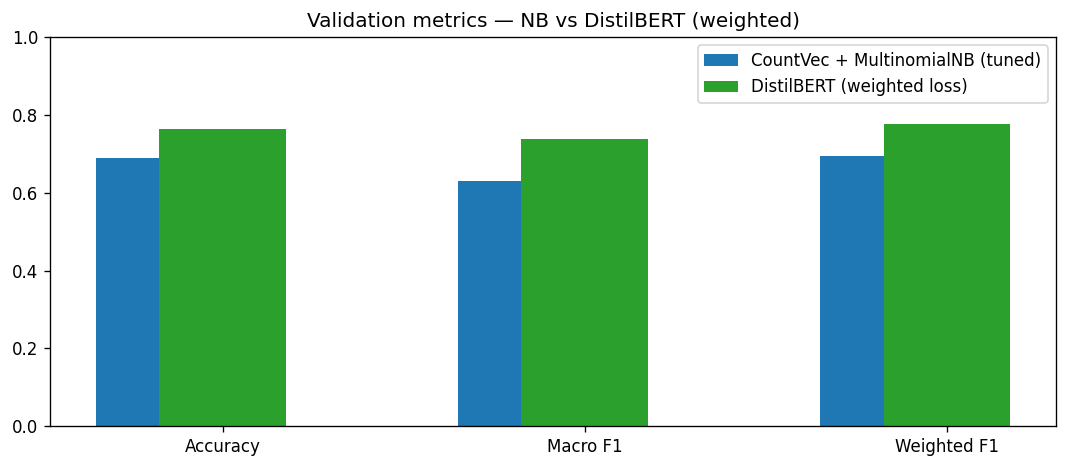

In [15]:
# =============================================================
# Cell 18 — Compare all methods on validation set
# =============================================================
val_results = pd.DataFrame([
    nb_val_summary,
    bert_w_val_summary
]).sort_values(by='macro_f1', ascending=False).reset_index(drop=True)

print('Validation results:')
print(val_results.to_string(index=False))

# Bar chart
metrics = ['accuracy', 'macro_f1', 'weighted_f1']
x       = np.arange(len(metrics))
width   = 0.35
models  = [nb_val_summary, bert_w_val_summary]
colors  = ['tab:blue', 'tab:green']

fig, ax = plt.subplots(figsize=(9, 4))
for i, (m, c) in enumerate(zip(models, colors)):
    ax.bar(x + (i - 1) * width / 2, [m[k] for k in metrics], width, label=m['model'], color=c)

ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'Macro F1', 'Weighted F1'])
ax.set_ylim(0, 1)
ax.set_title('Validation metrics — NB vs DistilBERT (weighted)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Stage 5 — Final Test Evaluation (best model only)

The test set is touched **only here**. Best model is selected by val macro F1.

Best model (by val macro F1): DistilBERT (weighted loss)



Final test summary: {'model': 'DistilBERT (weighted loss)', 'accuracy': 0.7867730900798175, 'macro_f1': 0.763234178066714, 'weighted_f1': 0.7979219542661682}

              precision    recall  f1-score   support

    negative     0.4957    0.8992    0.6391       129
     neutral     0.9426    0.7340    0.8254       470
    positive     0.8267    0.8237    0.8252       278

    accuracy                         0.7868       877
   macro avg     0.7550    0.8190    0.7632       877
weighted avg     0.8401    0.7868    0.7979       877



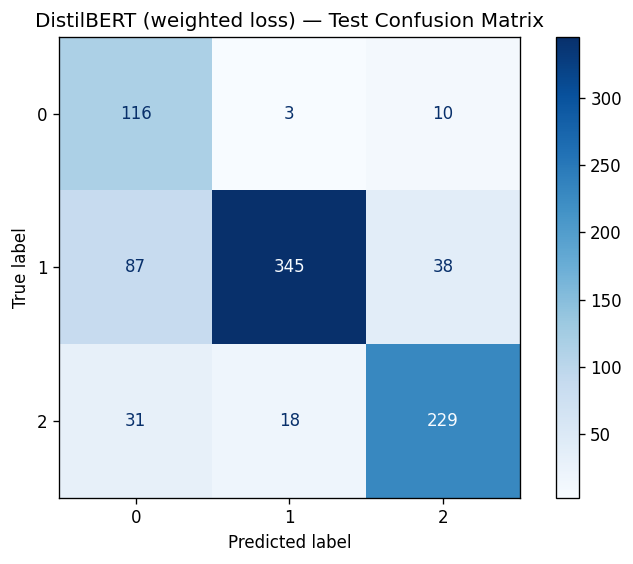

In [16]:
# =============================================================
# Cell 19 — Select best model and evaluate on test set
# =============================================================
best_summary = max(
    [nb_val_summary, bert_w_val_summary],
    key=lambda d: d['macro_f1']
)
best_name = best_summary['model']
print(f'Best model (by val macro F1): {best_name}')

if best_name == 'CountVec + MultinomialNB (tuned)':
    test_pred_raw = best_nb.predict(X_test_nb)
    test_true_raw = y_test
    label_names   = LABEL_ORDER

else:  # DistilBERT weighted
    out           = trainer_weighted.predict(test_ds)
    test_pred_raw = np.argmax(out.predictions, axis=-1)
    test_true_raw = np.array(test_ds['label'])
    label_names   = list(range(3)) 

test_summary = {
    'model':       best_name,
    'accuracy':    accuracy_score(test_true_raw, test_pred_raw),
    'macro_f1':    f1_score(test_true_raw, test_pred_raw, average='macro'),
    'weighted_f1': f1_score(test_true_raw, test_pred_raw, average='weighted')
}

print('\nFinal test summary:', test_summary)
print()
print(classification_report(test_true_raw, test_pred_raw, target_names=LABEL_ORDER, digits=4))
plot_confusion(test_true_raw, test_pred_raw, list(range(3)), f'{best_name} — Test Confusion Matrix')

---
## Stage 6 — Error Analysis

In [17]:
# =============================================================
# Cell 20 — Misclassified examples from best model
# =============================================================
if best_name == 'CountVec + MultinomialNB (tuned)':
    _, errors = error_df(X_test_nb, y_test, test_pred_raw)
else:
    # Reconstruct readable text from original df for display
    X_test_display = df.loc[idx_test, text_col].reset_index(drop=True)
    pred_labels    = pd.Series([ID2LABEL[p] for p in test_pred_raw])
    true_labels    = pd.Series([ID2LABEL[t] for t in test_true_raw])
    err_all        = pd.DataFrame({'text': X_test_display, 'true': true_labels, 'pred': pred_labels})
    errors         = err_all[err_all['true'] != err_all['pred']]

print(f'Total errors: {len(errors)} / {len(idx_test)}')
print('\nError breakdown by (true, predicted):')
print(errors.groupby(['true', 'pred']).size().rename('count').reset_index().to_string(index=False))
print('\nSample misclassified examples (25):')
print(errors[['true', 'pred', 'text']].head(25).to_string(index=False))

Total errors: 187 / 877

Error breakdown by (true, predicted):
    true     pred  count
negative  neutral      3
negative positive     10
 neutral negative     87
 neutral positive     38
positive negative     31
positive  neutral     18

Sample misclassified examples (25):
    true     pred                                                                                                                                                                                                                                                               text
 neutral positive                                                                                          The report also said Nokia 's operations comprising the sites at Bochum , Ulm , Dusseldorf , Munich and Frankfurt posted operating profit after interest of 246 mln eur .
 neutral negative                                                                                                             The company confirmed its estimate for lower 

---
## Save Results

In [18]:
# =============================================================
# Cell 21 — Save results to CSV
# =============================================================
val_results.to_csv('task2_val_results.csv',   index=False)
errors.head(25).to_csv('task2_errors.csv',    index=False)

print('Saved:')
print('  task2_val_results.csv')
print('  task2_errors.csv')

Saved:
  task2_val_results.csv
  task2_errors.csv
